In [21]:
import sys
from pathlib import Path

repo_root = Path("/Documents/Cellular-Automata")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [22]:
import numpy as np
from libs.Geometry import Geometry
from libs.rules.GameOfLife3D import GameOfLife3D
from libs.Sim import CellularAutomaton
from libs.tracking.StateTracker import StateTracker

## Run an examplary simulation

In [23]:
grid_dims = (100, 100, 50)
geometry = Geometry(size=grid_dims, axes="xyz", periodicity="xyz")

rule = GameOfLife3D(geometry=geometry, target_key="alive", time_step=1)
tracker = StateTracker(keys=["alive"])

sim = CellularAutomaton(geometry=geometry, rules=[rule], max_steps=30, tracker=tracker)
while sim.step_no < sim.max_steps:
    sim.step()

output_name = "simulation_visualisation"

tracker.save(output_name)

Simulation saved to: output_files/tracked_simulations/simulation_visualisation.npz


## Load the saved file into an array

In [24]:
with np.load("output_files/tracked_simulations/simulation_visualisation.npz") as data:
    alive_layer = data["alive"]

## Examplary plot of a timestep at a certain depth

In [25]:
import matplotlib.pyplot as plt


def plot_step(step_no, depth):
    step_data = alive_layer[step_no]

    z_level = depth
    slice_2d = step_data[:, :, z_level]

    plt.figure(figsize=(5, 5))
    plt.imshow(slice_2d, cmap="Greens", origin="lower")

    plt.title(f"alive layer, depth {z_level}, step {step_no}")
    plt.xlabel("Y axis")
    plt.ylabel("X axis")

    plt.grid(color="black", linestyle="-", linewidth=0.5, alpha=0.2)
    plt.show()

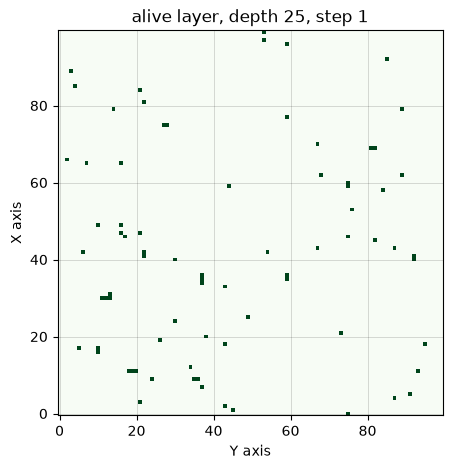

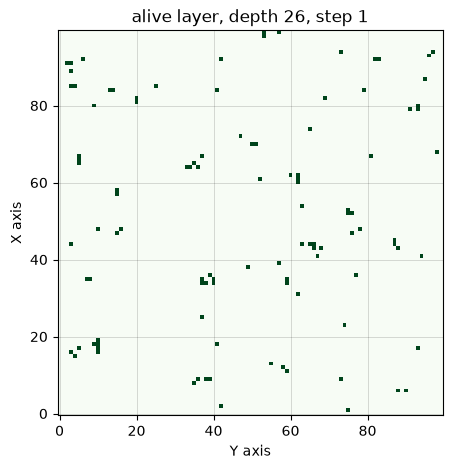

In [26]:
step_no = 1
depth = 25
plot_step(step_no=step_no, depth=depth)
plot_step(step_no=step_no, depth=depth + 1)

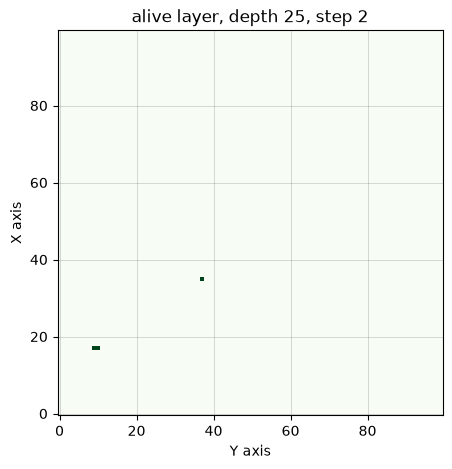

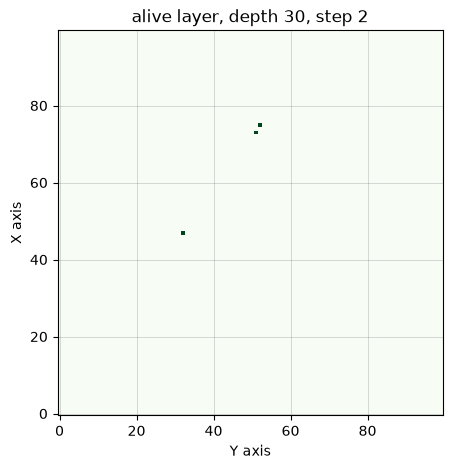

In [40]:
step_no = 2
depth = 25
plot_step(step_no=step_no, depth=depth)
plot_step(step_no=step_no, depth=depth + 5)

## Count of alive cells


In [28]:
def plot_alive_count(alive_layer: np.ndarray) -> None:

    alive_counts = np.count_nonzero(alive_layer, axis=(1, 2, 3))

    plt.figure(figsize=(6, 4))
    plt.plot(alive_counts, marker="o", color="green", linestyle="-")

    plt.title("total alive cells over time")
    plt.xlabel("time step")
    plt.ylabel("population of alive cells")

    plt.grid(color="black", linestyle="-", linewidth=0.5, alpha=0.2)
    plt.tight_layout()
    plt.show()

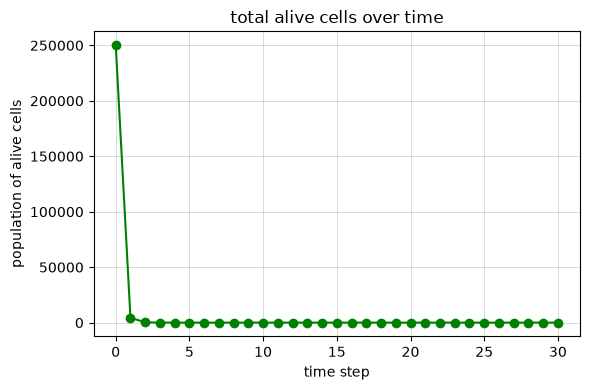

In [29]:
plot_alive_count(alive_layer)

## Plot the same step from different perspectives

In [30]:
def plot_step_3_perspectives(alive_layer, step_no, depth):

    step_data = alive_layer[step_no]

    x_max, y_max, z_max = step_data.shape
    x_depth = min(depth, x_max - 1)
    y_depth = min(depth, y_max - 1)
    z_depth = min(depth, z_max - 1)

    slice_xy = step_data[:, :, z_depth]  # slice across z
    slice_xz = step_data[:, y_depth, :]  # slice across y
    slice_yz = step_data[x_depth, :, :]  # slice across x

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    plt.suptitle(f"perspectives - step {step_no}", fontsize=14)

    axes[0].imshow(slice_xy, cmap="Greens", origin="lower", vmin=0, vmax=1)
    axes[0].set_title(f"XY plane (z-level {z_depth})")
    axes[0].set_xlabel("Y axis")
    axes[0].set_ylabel("X axis")

    axes[1].imshow(slice_xz, cmap="Greens", origin="lower", vmin=0, vmax=1)
    axes[1].set_title(f"XZ plane (y-level {y_depth})")
    axes[1].set_xlabel("Z axis")
    axes[1].set_ylabel("X axis")

    axes[2].imshow(slice_yz, cmap="Greens", origin="lower", vmin=0, vmax=1)
    axes[2].set_title(f"YZ plane (x-level {x_depth})")
    axes[2].set_xlabel("Z axis")
    axes[2].set_ylabel("Y axis")

    for ax in axes:
        ax.grid(color="black", linestyle="-", linewidth=0.5, alpha=0.2)

    plt.tight_layout()
    plt.show()

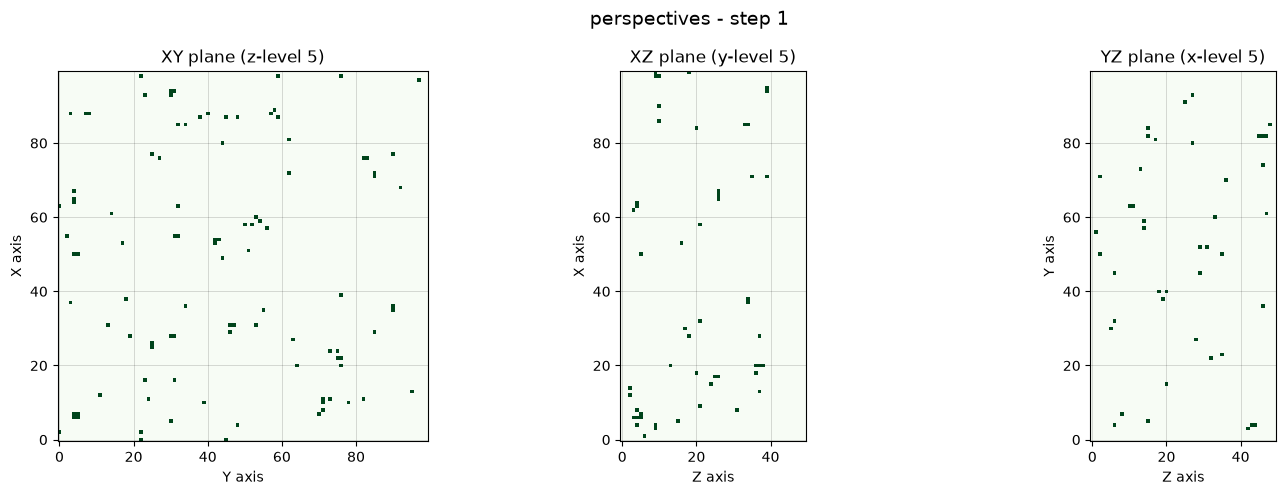

In [31]:
plot_step_3_perspectives(alive_layer, step_no=1, depth=5)

## Simulation with more species on grid

In [ ]:
import matplotlib.patches as mpatches
from libs.config.Parser import parse_json

In [33]:
config_filename = "multispecies_experiment.json"

sim, _ = parse_json(config_filename)

while sim.step_no < sim.max_steps:
    sim.step()

key mismatch between rules and state arrays (soft error)
Simulation saved to: output_files/tracked_simulations/multispecies_experiment.npz


In [34]:
history = sim.tracker.get_history()
red_data = history["bact_red"]
green_data = history["bact_green"]
blue_data = history["bact_blue"]

In [35]:
def plot_progress(z_level):
    total_frames = len(red_data)
    z_level = z_level

    frames_to_plot = [0, total_frames // 3, (2 * total_frames) // 3, total_frames - 1]

    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    axes = axes.flatten()

    legend_handles = [
        mpatches.Patch(color="red", label="red (kills green)"),
        mpatches.Patch(color="green", label="green (kills blue)"),
        mpatches.Patch(color="blue", label="blue (kills red)"),
    ]

    for ax, frame in zip(axes, frames_to_plot):
        safe_frame = min(max(frame, 0), total_frames - 1)

        r_slice = red_data[safe_frame][:, :, z_level]
        g_slice = green_data[safe_frame][:, :, z_level]
        b_slice = blue_data[safe_frame][:, :, z_level]

        rgb_frame = np.stack([r_slice, g_slice, b_slice], axis=-1)
        rgb_frame = (np.clip(rgb_frame, 0, 1) * 255).astype(np.uint8)

        ax.imshow(rgb_frame, origin="lower")
        ax.set_title(f"sim step: {safe_frame}")
        ax.set_xlabel("X axis")
        ax.set_ylabel("Y axis")

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=3,
        fontsize=12,
    )

    plt.tight_layout()
    plt.show()

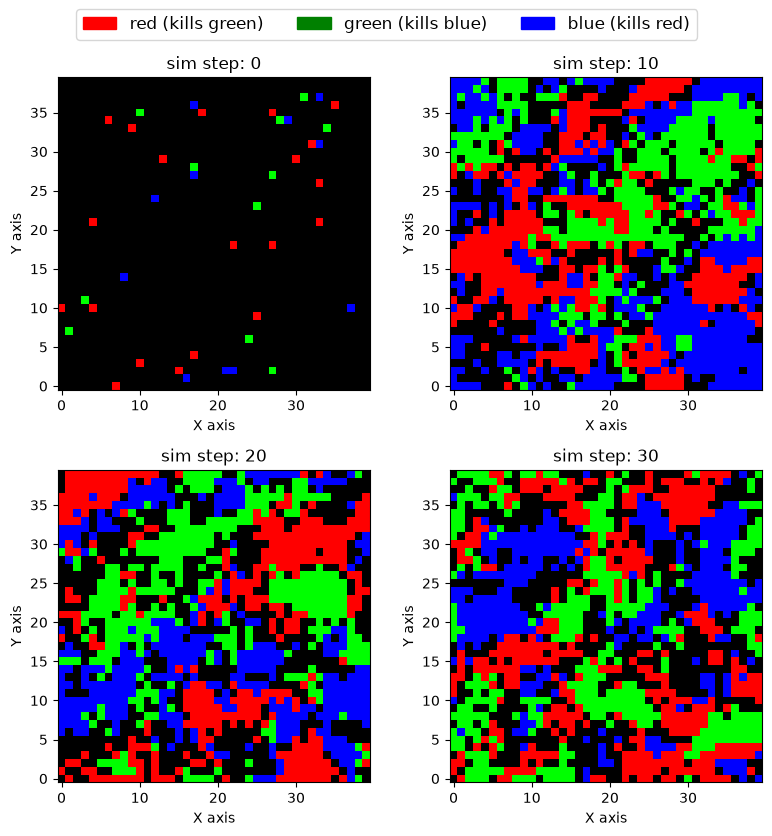

In [36]:
plot_progress(z_level=5)

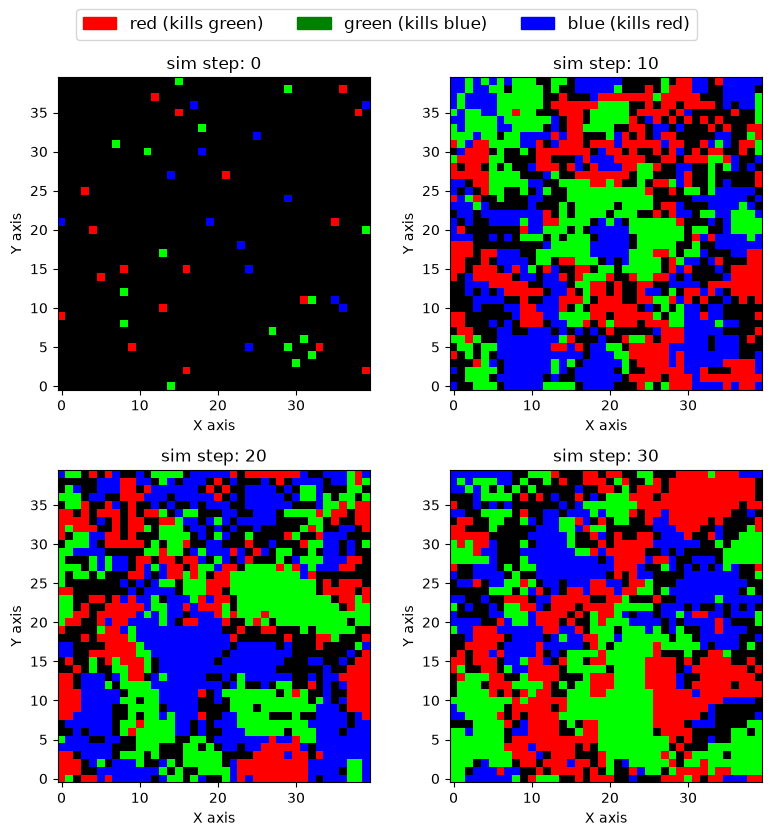

In [37]:
plot_progress(z_level=1)

In [49]:
def plot_3d(step_no=-1):

    frame_idx = step_no

    r_vol = red_data[frame_idx]
    g_vol = green_data[frame_idx]
    b_vol = blue_data[frame_idx]

    r_x, r_y, r_z = np.nonzero(r_vol)
    g_x, g_y, g_z = np.nonzero(g_vol)
    b_x, b_y, b_z = np.nonzero(b_vol)

    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(r_x, r_y, r_z, c="red", marker="s", alpha=0.6, s=15, label="red")
    ax.scatter(g_x, g_y, g_z, c="green", marker="s", alpha=0.6, s=15, label="green")
    ax.scatter(b_x, b_y, b_z, c="blue", marker="s", alpha=0.6, s=15, label="blue")

    grid_x, grid_y, grid_z = sim.geometry.size
    ax.set_xlim(0, grid_x)
    ax.set_ylim(0, grid_y)
    ax.set_zlim(0, grid_z)

    ax.set_xlabel("X axis")
    ax.set_ylabel("Y axis")
    ax.set_zlabel("Z axis")

    ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1))

    plt.tight_layout()
    plt.show()

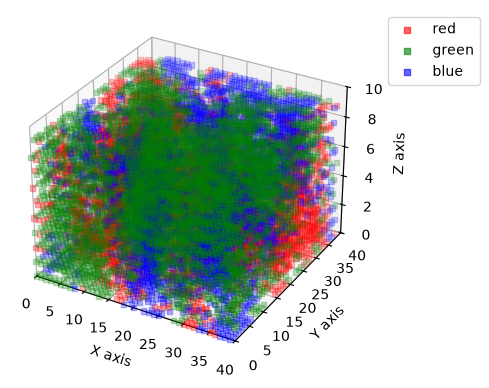

In [50]:
plot_3d()

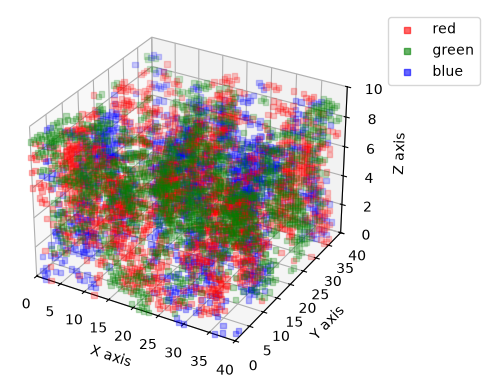

In [51]:
plot_3d(2)